<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>

# __Autoencoder with Python__



In this lab, we will first review how to build a shallow autoencoder using the Keras functional API and the Model subclassing. Then, we will review some applications of autoencoders such as image denoising and image compression. Lastly, we will use what we have learned in the later sections to build deeper autoencoders.

As the figure shows below, when used on images, autoencoders can not only return the reconstructed image but also return a compressed version of it. The compressed data is very useful as it achieves the goal of dimensionality reduction while retaining meaningful information from the image. We will soon dive deep into how different types of autoencoders help us realize all these goals!

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module5/L2/intro_pic.png" width="65%" style="vertical-align:middle;margin:30px 0px"></center>

Image credits to [Yifei Zhang](https://www.semanticscholar.org/paper/A-Better-Autoencoder-for-Image%3A-Convolutional-Zhang/b1786e74e233ac21f503f59d03f6af19a3699024?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01)


## **Table of Contents**

1. [Objectives](#toc-objectives)
2. [Setup](#toc-setup)
    1. [Installing Required Libraries](#toc-installing-required-libraries)
    2. [Importing Required Libraries](#toc-importing-required-libraries)
    3. [Defining Helper Functions](#toc-defining-helper-functions)
3. [Introduction](#toc-introduction)
4. [Shallow Autoencoders](#toc-shallow-autoencoders)
    1. [Autoencoders using the Functional API](#toc-autoencoders-using-the-functional-api)
    2. [Autoencoders using Model Subclassing](#toc-autoencoders-using-model-subclassing)
5. [Applications of Autoencoders](#toc-applications-of-autoencoders)
    1. [Anomaly Detection with Autoencoders](#toc-anomaly-detection-with-autoencoders)
    2. [Denoising Autoencoders](#toc-denoising-autoencoders)
    3. [Exercise 1](#toc-exercise-1)
    4. [Exercise 2](#toc-exercise-2)
6. [Deep Autoencoders](#toc-deep-autoencoders)
    1. [Loading Images From a Directory for Autoencoders](#toc-loading-images-from-a-directory-for-autoencoders)
7. [Convolutional Autoencoders](#toc-convolutional-autoencoders)


## <a id="toc-objectives"></a>**Objectives**

After completing this lab, you will be able to:

 - Apply Autoencoders to real world problems 
 - Implement different autoencoder architecture
 - Train different autoencoders 


----


## <a id="toc-setup"></a>**Setup**

For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


### <a id="toc-installing-required-libraries"></a>**Installing Required Libraries**

The following required libraries are pre-installed in the Skills Network Labs environment. However, if you run these notebook commands in a different Jupyter environment (like Watson Studio or Anaconda), you will need to install these libraries by removing the `#` sign before `!mamba` in the following code cell.


In [1]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy numpy==1.22.3 matplotlib==3.5.1 tensorflow==2.9.0 opencv-python==4.5.5.62

# Note: If your environment doesn't support "!mamba install", use "!pip install --user"

# RESTART YOUR KERNEL AFTERWARD AS WELL

Upgrade the tensorflow and skillsnetwork library:


%%capture
!pip install --upgrade tensorflow
!pip install --upgrade skillsnetwork

### <a id="toc-importing-required-libraries"></a>**Importing Required Libraries**

*We recommend you import all required libraries in one place (here):*


In [2]:
import os
import copy
import skillsnetwork

import numpy as np
from numpy.core.fromnumeric import reshape

import tensorflow as tf

tf.config.set_visible_devices([], "GPU")

import keras
from keras import layers, Input, Sequential
from keras.layers import Dense, Flatten, Reshape, Conv2DTranspose, Conv2D
from keras.models import Model


from keras.layers import Conv2D


def warn(*args, **kwargs):
    pass


import warnings

warnings.warn = warn
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

2026-05-28 15:49:59.396644: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-28 15:49:59.396872: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-28 15:49:59.420090: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-28 15:50:00.046428: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different compu

### <a id="toc-defining-helper-functions"></a>**Defining Helper Functions**
The following helper functions keep the notebook code shorter and make the results easier to visualize.

`plot_images` displays two rows of images so we can compare original inputs with reconstructed, encoded, or denoised outputs.

In [3]:
def plot_images(
    top, bottom, start=0, stop=5, reshape_x=(28, 28), reshape_xhat=(28, 28)
):
    """
    this function plots images from the start index to the stop index from two datasets

    """
    # Calculates how many images will be plotted
    n_samples = stop - start

    for i, img_index in enumerate(range(start, stop)):

        # Display original
        ax = plt.subplot(2, n_samples, i + 1)
        plt.imshow(
            top[img_index].reshape(reshape_x[0], reshape_x[1]), cmap="gray"
        )

        if i == n_samples // 2:
            plt.title("original images")

        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        # Display reconstruction
        ax = plt.subplot(2, n_samples, i + 1 + n_samples)
        plt.imshow(
            bottom[img_index].reshape(reshape_xhat[0], reshape_xhat[1]),
            cmap="gray",
        )

        if i == n_samples // 2:
            plt.title("encoded images")

        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

`graph_history` plots the values saved during model training, such as training loss and validation loss. We use it to check whether the autoencoder is improving over the epochs.


In [4]:
def graph_history(history, title="Log Loss and Accuracy over iterations"):

    fig = plt.figure(figsize=(16, 8))
    fig.suptitle(title)
    N_plots = len(history.history.keys())
    color_list = ["b", "r", "g", "c", "m", "y", "k", "w", "bx", "rx"]
    for i, (key, items) in enumerate(history.history.items()):
        ax = fig.add_subplot(1, N_plots, i + 1)
        ax.plot(items, c=color_list[i])
        ax.grid(True)
        ax.set(xlabel="iterations", title=key)

`add_noise` creates noisy versions of the training and test images. We use these noisy images later to train a denoising autoencoder.


In [5]:
def add_noise(x_train, x_test, noise_factor=0.3):
    """
    this function adds random values from a normal distribution as noises to the data

    returns the noisy datasets

    """
    noise_factor = 0.3
    x_train_noisy = x_train + noise_factor * tf.random.normal(
        shape=x_train.shape
    )
    x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape)

    x_train_noisy = tf.clip_by_value(
        x_train_noisy, clip_value_min=0.0, clip_value_max=1.0
    ).numpy()
    x_test_noisy = tf.clip_by_value(
        x_test_noisy, clip_value_min=0.0, clip_value_max=1.0
    ).numpy()

    return x_train_noisy, x_test_noisy

`plot_code` visualizes the encoder output in 3D. It helps us see whether images from different digit classes form separate groups in the low-dimensional latent space.


In [6]:
def plot_code(h, y, numbers=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], scale=[1, 1, 1]):
    """
    number: list of classes to be plotted
    scale: scale activations to plot better

    """
    h = h.numpy()
    color_list = [
        "b",
        "g",
        "r",
        "c",
        "m",
        "y",
        "k",
        "pink",
        "darkorange",
        "lime",
    ]
    logic_array = np.zeros(len(y), dtype=bool)

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection="3d")

    for num, color in zip(numbers, color_list):
        logic_array = y == num
        plt.scatter(
            scale[0] * h[logic_array, 0],
            scale[1] * h[logic_array, 1],
            scale[2] * h[logic_array, 2],
            c=color,
            label=num,
        )

    plt.title("3D output of encoder, colored by digits")
    plt.legend(loc=[1.1, 0.3])
    plt.show()

The `avg` initializer and `a_conv` layer create a simple averaging filter. Later, this filter is used to blur images before training a convolutional autoencoder to recover sharper images.


In [7]:
import keras.ops as ops


def avg(shape, dtype=None):
    grad = np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]]).reshape((3, 3, 1, 1)) / 9

    assert grad.shape == shape
    return ops.convert_to_tensor(grad, dtype="float32")


a_conv = layers.Conv2D(
    filters=1, kernel_size=3, kernel_initializer=avg, strides=1, padding="same"
)

`display_auto` shows one input-output pair from an image dataset iterator. It is useful later when we inspect the paired images used for autoencoder training.


In [8]:
def display_auto(Xiter, n=1, B=1):
    """
    This function displays the ouput of an autoencder
    Returns:  void images
    Args:
    Xiter:image_dataset_from_directory object converted to iterator
    n:sample within batch
    B: batch number
    """

    for b in range(B):
        x = next(Xiter)

        plt.imshow(x[1].numpy()[n, :, :, 0], cmap="gray")
        plt.title("input")
        plt.show()
        plt.imshow(x[0].numpy()[n, :, :, 0], cmap="gray")
        plt.title("output")
        plt.show()

## <a id="toc-introduction"></a>**Introduction**

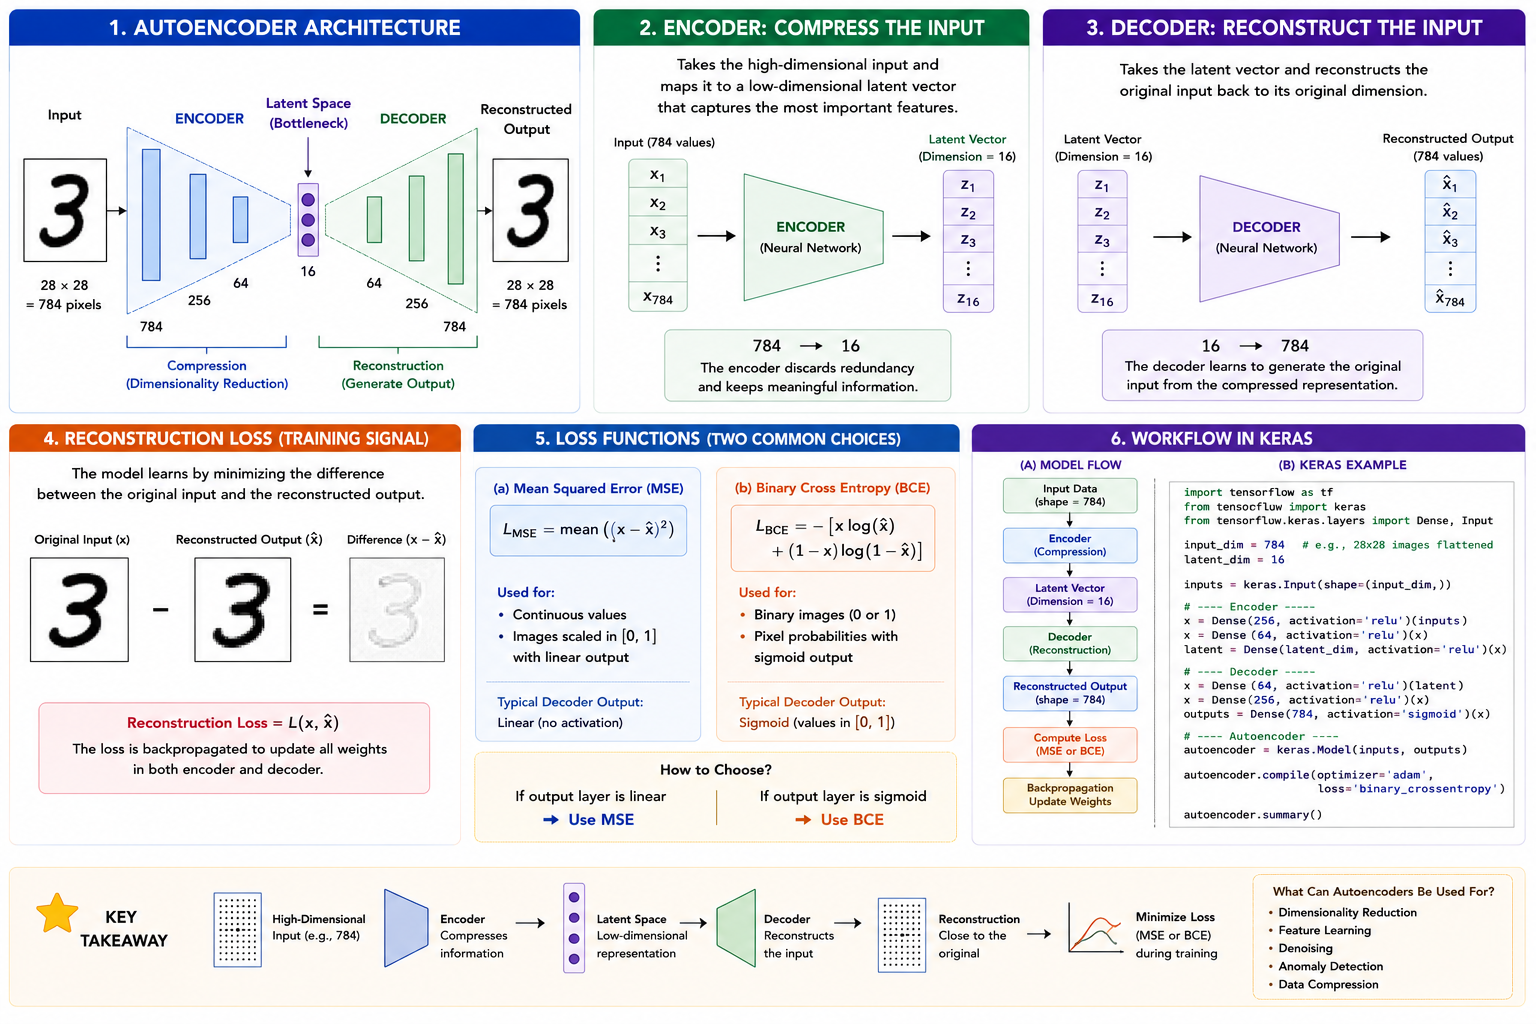

An autoencoder is a neural network designed to learn a compressed representation of input data by minimizing the difference between the input and the output. The network consists of two main parts:

1. **The Encoder**: The encoder compresses the input $\textbf{X}$ into a lower-dimensional latent space, producing a vector known as the **embedding** (or code) $\textbf{Z}$, such that $\textbf{Z} = \textbf{E(X)}$. This embedding acts as a "bottleneck," forcing the network to discard noise and retain only the most essential features of the data.

2. **The Decoder**: The decoder then attempts to reconstruct the original input from this embedding, producing $\hat{\textbf{X}} = \textbf{D(Z)}$.

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module5/L2/flow.png" width="60%" style="vertical-align:middle;margin:50px 0px"></center>

In general, $\textbf{D(E(X))} = \hat{\textbf{X}}$, where $\hat{\textbf{X}}$ is an approximation of $\textbf{X}$. This process forces the model to learn useful properties of the data, which is highly valuable in applications such as image enhancement and outlier detection.

### **Text vs. Image Embeddings** 

**Text Embeddings:** Discrete $\rightarrow$ Continuous
Text is **discrete**. A word like "apple" has no inherent numerical value; it is simply a symbol.

*   **The Lookup Table**: To handle this, we use an **Embedding Layer**, which is essentially a giant lookup table. For example, if you have a vocabulary of 10,000 words, the table contains 10,000 rows.
*   **Why they start random**: When training begins, the model has no prior knowledge of what "apple" means, so it assigns a **random vector** to that word. As the model trains (e.g., by predicting the next word in a sentence), it adjusts these vectors so that words with similar meanings are positioned close to each other in the latent space.
*   **The Process**: 
    `Word ID` $\rightarrow$ `Lookup Table` $\rightarrow$ `Embedding Vector`

**Image Embeddings:** Continuous $\rightarrow$ Continuous \
Images are already **continuous numerical data**. An image is represented as a grid of pixel intensities (e.g., values ranging from 0 to 255).

*   **The Feature Extractor**: Because the input is already numerical, a lookup table is unnecessary. Instead, we use a **Neural Network (the Encoder)** to transform the data.
*   **How they are generated**: The image passes through various layers (such as Convolutional or Dense layers). These layers perform mathematical operations—primarily multiplication and addition—on the pixel values. The final output of the encoder is the embedding.
*   **The "Random" Part**: While the embedding itself is not a random lookup, the **weights** of the encoder network are initialized as random numbers. Consequently, the first time an image passes through a fresh encoder, the resulting embedding will be essentially random. As the autoencoder trains to reconstruct the image, it optimizes these weights to ensure the embedding captures the most salient visual features (such as edges, shapes, and textures).
*   **The Process**: 
    `Pixel Grid` $\rightarrow$ `Encoder Network (Weights)` $\rightarrow$ `Embedding Vector`


### **Reconstruction Loss**

In an autoencoder, the goal is to compress the input into a latent-space representation and then reconstruct the original input from that representation. The **Reconstruction Loss** measures how much information was lost during this process.

In a typical supervised model, you have an input $X$ and a target $Y$. In an autoencoder, the target is the input itself.

- **Input:** $X$ (the original image)
- **Output:** $\hat{X}$ (the reconstructed image)
- **Goal:** make $\hat{X}$ as similar to $X$ as possible.

#### **1. Mean Squared Error (MSE)**
If the image pixels are treated as continuous values (e.g., normalized between 0 and 1), MSE is commonly used. It calculates the average squared difference between the original input $x$ and the reconstructed output $\hat{x}$.

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{x}_i)^2$$

*   **Use case:** Best for continuous data or when the noise is assumed to be Gaussian.

#### **2. Binary Cross-Entropy (BCE)**
If the pixels are treated as probabilities (common in MNIST where pixels are often normalized to $[0 ,1]$, Binary Cross-Entropy is often more effective.

$$\text{BCE} = -\frac{1}{n} \sum_{i=1}^{n} [x_i \log(\hat{x}_i) + (1 - x_i) \log(1 - \hat{x}_i)]$$

*   **Use case:** Best for binary data or normalized values where you want to penalize "confident" wrong predictions more heavily.

## <a id="toc-shallow-autoencoders"></a>**Shallow Autoencoders**

They are the simplest autoencoders, which typically consist of a one-layer encoder followed by a one-layer decoder. The encoder can have an activation function or not. Similarly, the decoder can have a real output or a bounded output, for example, between 0 and 1.

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module5/L2/shallow_model.png" width="45%" style="vertical-align:middle;margin:30px 0px"></center>


Let's use the MNIST data from `keras.datasets` as a beginning example:


The image data are stored as 2D grids (e.g., $28 \times 28$ pixels), but standard Dense (fully connected) layers require a 1D vector as input.The following code uses flattening to convert the 2D image into a single long row of pixels.  A $28 \times 28$ image is transformed into a vector of 784 elements. This allows the neural network to process each pixel as an individual feature, enabling the model to perform terms of terms of weighted sums across the entire image.

In [9]:
from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()


x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


Here we introduce two ways to build shallow autoencoders in Keras, one is using the **Keras functional API**, and the other one is **subclassing the Keras Model class**. 


### <a id="toc-autoencoders-using-the-functional-api"></a>**Autoencoders using the Functional API**

The Functional API treats each layer like a function. A layer receives a tensor as input and returns a tensor as output. This gives us more flexibility than the Sequential API because we can connect layers in different ways, reuse layers, or build models with multiple inputs and outputs.

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module5/L2/functional_API.png" width="30%" style="vertical-align:middle;margin:0px 0px"></center>


First, we create the input layer, `input_img`. Each image has been flattened into a vector of 784 values, so the input shape is `(784,)`.


In [10]:
input_img = Input(shape=(784,))

Next, we create the encoder. The Dense layer compresses the 784 input values into `encoding_dim` values. We use the ReLU activation, and we pass `input_img` to the layer to connect it to the model input.


In [11]:
encoding_dim = 36
encoder = Dense(encoding_dim, activation="relu")(input_img)

Then, we create the decoder. This Dense layer expands the encoded representation back to 784 values, matching the original image size. Since the pixel values are scaled between 0 and 1, we use a sigmoid activation for the output. We pass `encoder` to this layer so the decoder receives the compressed representation as input.


In [12]:
decoder = Dense(784, activation="sigmoid")(encoder)

Now we build the autoencoder model. The model starts with `input_img` and ends with `decoder`, so it learns to map each image back to a reconstructed version of itself.


In [13]:
autoencoder = Model(input_img, decoder)

We compile the model with the Adam optimizer and binary cross-entropy loss. Mean squared error can also be used for reconstruction tasks.


In [14]:
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

We now train the autoencoder. In a normal supervised model, the training data and labels are different. For an autoencoder, the target is the original input, because the model is learning to reconstruct that input. Therefore, we pass `x_train` as both the input and the target, and we do the same with `x_test` for validation.


In [15]:
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=25,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
)

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2720 - val_loss: 0.1854
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1662 - val_loss: 0.1486
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1393 - val_loss: 0.1288
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1239 - val_loss: 0.1167
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1138 - val_loss: 0.1083
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1066 - val_loss: 0.1023
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1014 - val_loss: 0.0981
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0977 - val_loss: 0.0949
Epoch 9/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0950 - val_loss: 0.0926
Epoch 10/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0930 - val_loss: 0.0909
Epoch 11/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0917 - val_loss: 0.0899
Epoch 12/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

We can plot the training and validation loss over the epochs:


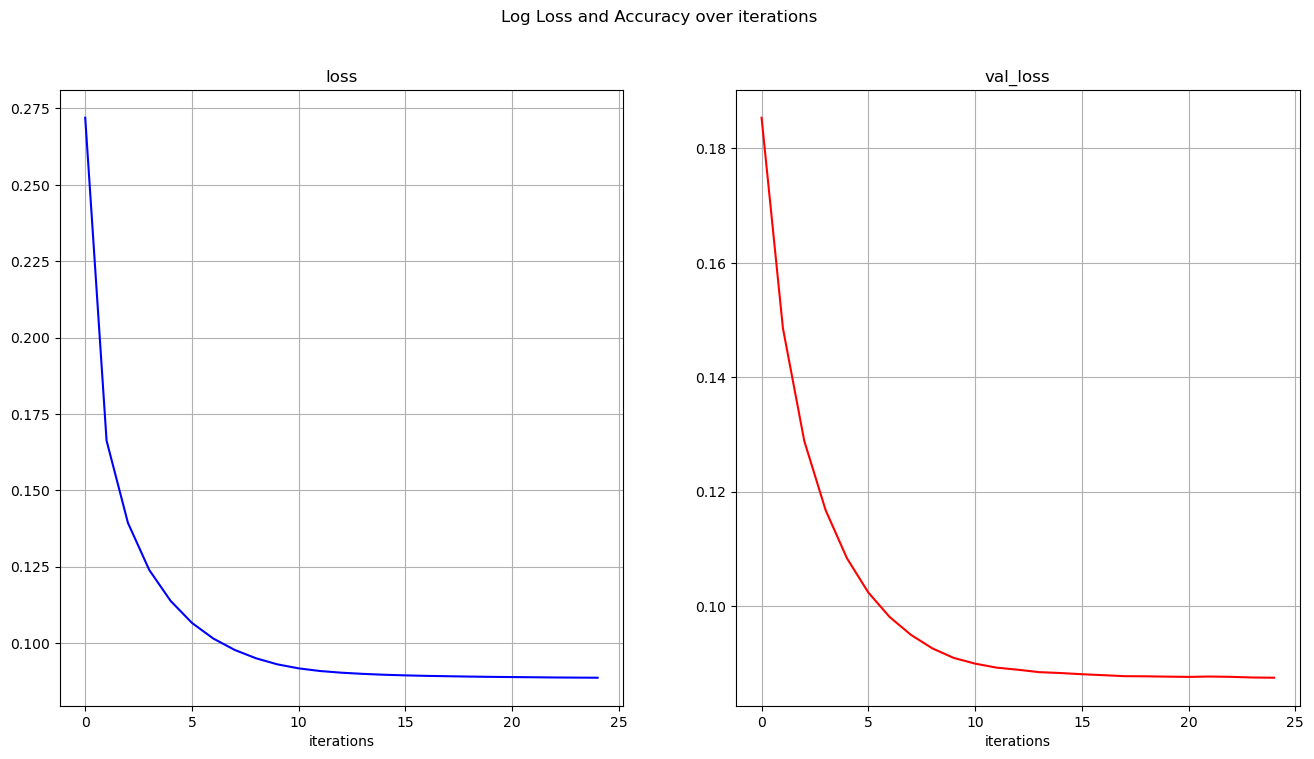

In [16]:
graph_history(history, title="Log Loss and Accuracy over iterations")

The loss decreases during training, and the validation loss stays close to the training loss. This suggests that the autoencoder is learning useful patterns from the data and is not overfitting strongly.


We use `predict` to reconstruct the test images with the trained autoencoder.


In [17]:
xhat = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 232us/step


Finally, we compare the reconstructed images with the original test images. The closer they look, the better the autoencoder has learned to preserve the important information in the input.


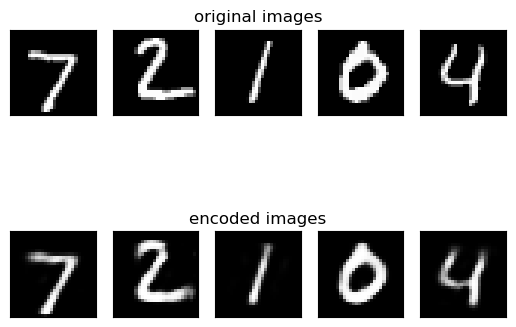

In [18]:
plot_images(x_test, xhat, start=0, stop=5)

### <a id="toc-autoencoders-using-model-subclassing"></a>**Autoencoders using Model Subclassing**

Keras also lets us build models with an object-oriented approach. In this approach, we create a new class that inherits from `tf.keras.Model`. This is called model subclassing. It is useful when we want to organize a model as a reusable Python class or define custom behavior inside the model.

Here, we create an `Autoencoder` class. The class contains an encoder layer, a decoder layer, and a `call` method that describes how data flows through the model.


In [19]:
class Autoencoder(tf.keras.Model):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = Dense(latent_dim, activation="relu")
        self.decoder = Dense(784, activation="sigmoid")

    def call(self, x):

        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

`latent_dim` is the size of the compressed representation. In this example, the encoder is a Dense layer that reduces each 784-value input image to `latent_dim` values:

`self.encoder = Dense(latent_dim, activation="relu")`

The decoder is another Dense layer that reconstructs the image by expanding the compressed representation back to 784 values:

`self.decoder = Dense(784, activation="sigmoid")`

The `call` method defines the forward pass. It sends the input through the encoder first and then through the decoder. Keras uses this method when the model is trained, evaluated, or used for prediction.


Now we create an `autoencoder` object from the `Autoencoder` class. The only value we need to provide is `encoding_dim`, which sets the size of the latent representation.


In [20]:
encoding_dim = 36
autoencoder = Autoencoder(encoding_dim)

This `autoencoder` object has the encoder, decoder, and `call` method that we defined. It also inherits the standard Keras model methods, such as `compile`, `fit`, `predict`, and `evaluate`.


The training steps are the same as in the Functional API example. We compile the model, train it with `x_train` as both the input and target, validate it with `x_test`, and plot the loss history.


Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2741 - val_loss: 0.1893
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1680 - val_loss: 0.1480
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1387 - val_loss: 0.1281
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1226 - val_loss: 0.1152
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1119 - val_loss: 0.1065
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1048 - val_loss: 0.1008
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1000 - val_loss: 0.0968
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0965 - val_loss: 0.0940
Epoch 9/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0941 - val_loss: 0.0920
Epoch 10/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0925 - val_loss: 0.0907
Epoch 11/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0914 - val_loss: 0.0898
Epoch 12/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

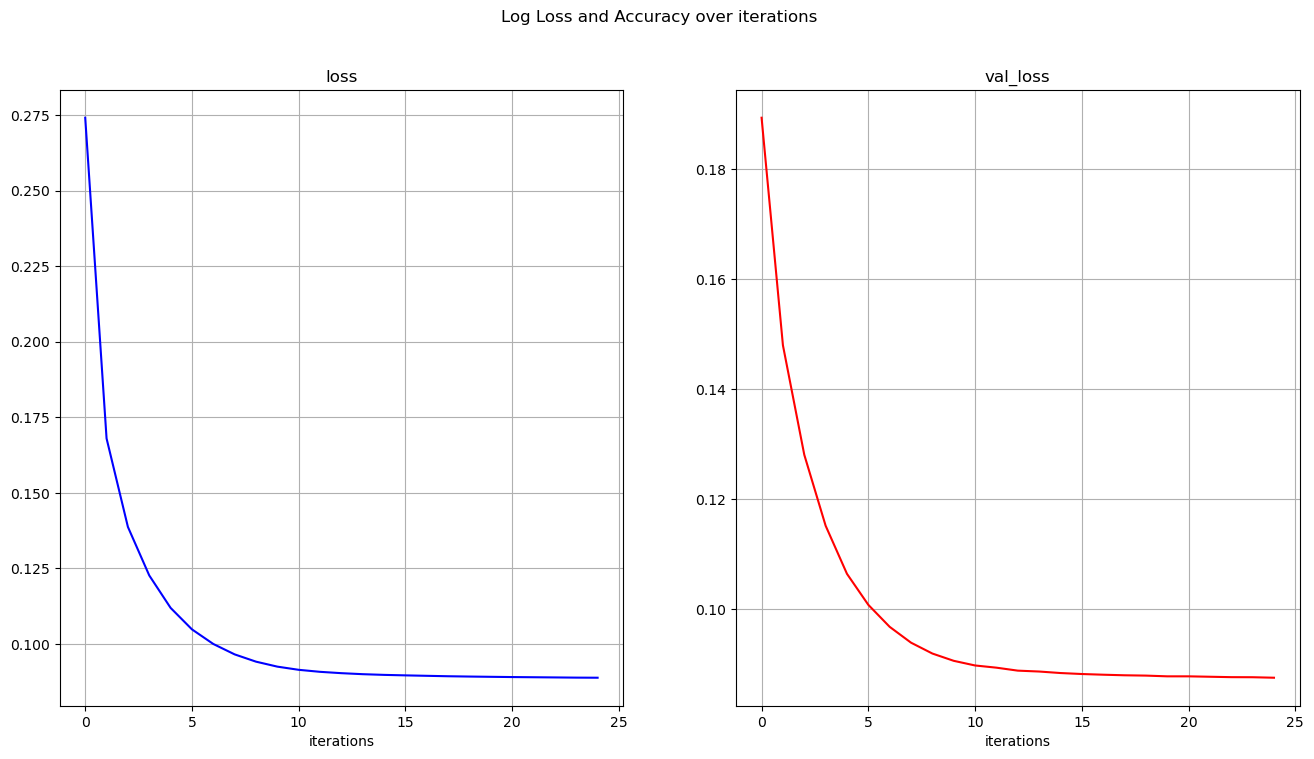

In [21]:
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=25,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
)
graph_history(history, title="Log Loss and Accuracy over iterations")

After training, we reconstruct test images and compare them with the original images.


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 238us/step


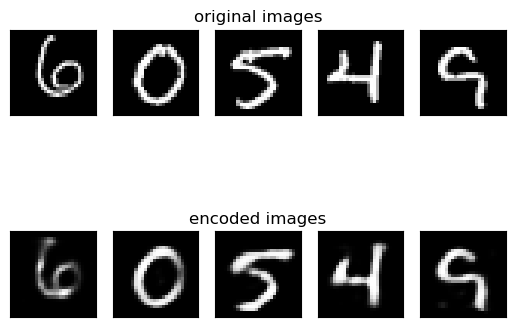

In [22]:
xhat = autoencoder.predict(x_test)
plot_images(x_test, xhat, start=100, stop=105)

We can also look at the compressed representation directly by calling the encoder layer. This returns the encoder output for each test image.


In [23]:
h = autoencoder.encoder(x_test)
h.shape

TensorShape([10000, 36])

The encoder output has 36 values for each image. To visualize these values as small images, we reshape each encoded vector to $6\times 6$.


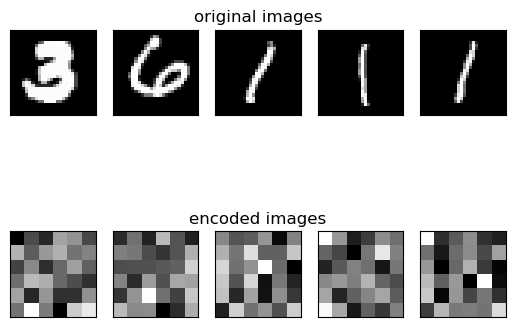

In [24]:
plot_images(
    x_test,
    h.numpy(),
    start=200,
    stop=205,
    reshape_x=(28, 28),
    reshape_xhat=(6, 6),
)

Should you use the Functional API or model subclassing? In most cases, the Functional API is simpler and easier to inspect. It works well when the model can be described as a clear graph of connected layers.

Model subclassing gives more flexibility. It is helpful when the model needs custom logic that is difficult to express as a standard layer graph, such as unusual control flow or a highly customized forward pass.

You do not have to choose only one style forever. Models built with the Sequential API, Functional API, and model subclassing can work together in `tf.keras`.


Now that you know how an autoencoder is built and trained, let's look at some real-world applications of autoencoders.


## <a id="toc-applications-of-autoencoders"></a>**Applications of Autoencoders**

Autoencoders are useful because they learn compact representations of data. In this section, we use that idea for anomaly detection, image denoising, and low-dimensional visualization.


### <a id="toc-anomaly-detection-with-autoencoders"></a>**Anomaly Detection with Autoencoders**
An autoencoder learns to reconstruct data that looks similar to the data it saw during training. If a sample is very different from the training data, the autoencoder usually reconstructs it poorly. This produces a larger reconstruction loss.

We can use this idea to detect possible anomalies. Samples with the largest reconstruction losses are treated as the most unusual samples.

First, we calculate the loss between each original test image and its reconstructed version from the previous autoencoder.


We create a binary cross-entropy loss function and use it to calculate the reconstruction loss for each test sample.


In [25]:
bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In autoencoders, we often want to find anomalies. If we only look at the average loss that Keras calculates across the whole batch or dataset, we know how the model performs overall, but we do not know which specific images it reconstructed poorly.

By **calculating the loss for each image individually**, you can:

- **Sort the images:** find the images with the highest reconstruction error.
- **Identify outliers:** if most images have a low loss but one image has a much higher loss, that image may be an anomaly.
- **Visualize failures:** plot the images that the model struggled to reconstruct so we can better understand its weaknesses.

The following script creates one loss value for every test image.


In [26]:
loss = [bce(x, x_s).numpy() for x, x_s in zip(x_test, xhat)]

Next, we sort the sample indexes by loss. `np.argsort(loss)` does not sort the loss itself. Instead, it returns the indices that would sort the array. `np.flip` reverses that order, so the highest-loss samples come first.


In [27]:
indexs = np.flip(np.argsort(loss))

Now we plot the ten test images with the highest reconstruction losses. These are the samples the autoencoder found hardest to reconstruct.


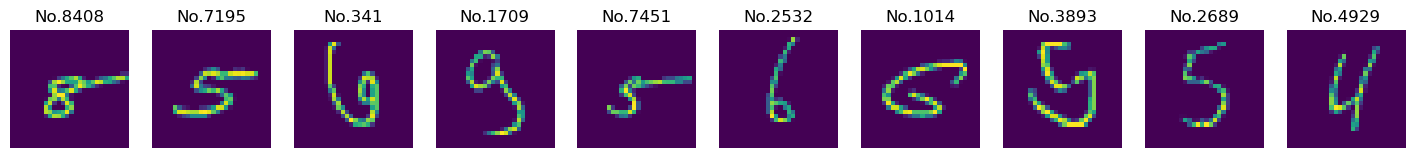

In [28]:
plt.figure(figsize=(18, 3))
for i, index in enumerate(indexs[0:10]):

    plt.subplot(1, 10, i + 1)
    plt.imshow(x_test[index].reshape(28, 28))
    plt.title(f"No.{index}")
    plt.axis("off")

### <a id="toc-denoising-autoencoders"></a>**Denoising Autoencoders**

We can also use autoencoders to remove noise from images. A denoising autoencoder learns to take a noisy image as input and reconstruct the clean version as output.

The following figure shows the basic idea:

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module5/L2/denoising.png" width="40%" style="vertical-align:middle;margin:15px 0px"></center>


First, we add artificial noise to the digit dataset using the helper function `add_noise`.


In [29]:
x_train_noisy, x_test_noisy = add_noise(x_train, x_test, noise_factor=0.4)

In [30]:
x_train_noisy.shape

(60000, 784)

We display a few original training images and their noisy versions to see how the data changed.


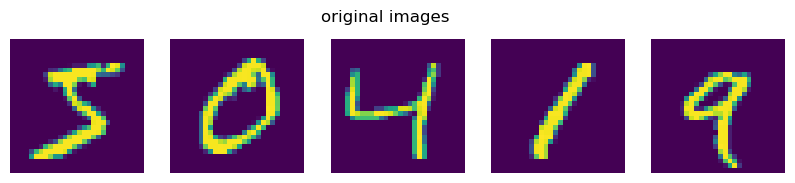

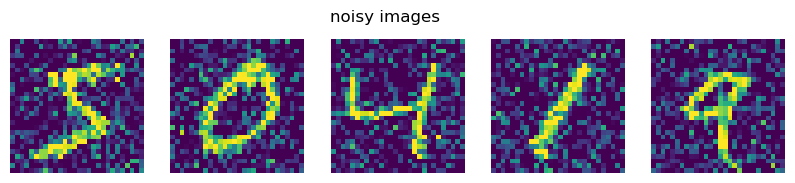

In [31]:
fig1 = plt.figure(figsize=(10, 2))
fig1.suptitle("original images")
fig2 = plt.figure(figsize=(10, 2))
fig2.suptitle("noisy images")

for i, img_index in enumerate(range(5)):
    ax1 = fig1.add_subplot(1, 5, i + 1)
    ax1.imshow(x_train[img_index].reshape((28, 28)))
    ax1.axis("off")
    ax2 = fig2.add_subplot(1, 5, i + 1)
    ax2.imshow(x_train_noisy[img_index].reshape((28, 28)))
    ax2.axis("off")

Here, we create a denoising autoencoder using the same `Autoencoder` class. We set the encoding dimension to twice the input dimension, giving the model enough capacity to learn how to recover the clean image from the noisy input.


In [32]:
encoding_dim = 2 * x_test.shape[1]
autoencoder = Autoencoder(encoding_dim)

We train the model with noisy images as inputs and clean images as targets. In other words, the model receives `x_train_noisy` and learns to output `x_train`. For validation, it receives `x_test_noisy` and compares its output with `x_test`. This forces the autoencoder to learn the important structure of the digits instead of simply copying the noise.


Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1450 - val_loss: 0.0960
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0913 - val_loss: 0.0874
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0863 - val_loss: 0.0850
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0842 - val_loss: 0.0836
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0829 - val_loss: 0.0829
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0820 - val_loss: 0.0823
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0812 - val_loss: 0.0820
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0806 - val_loss: 0.0814
Epoch 9/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0800 - val_loss: 0.0812
Epoch 10/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0796 - val_loss: 0.0809
Epoch 11/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0791 - val_loss: 0.0807
Epoch 12/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

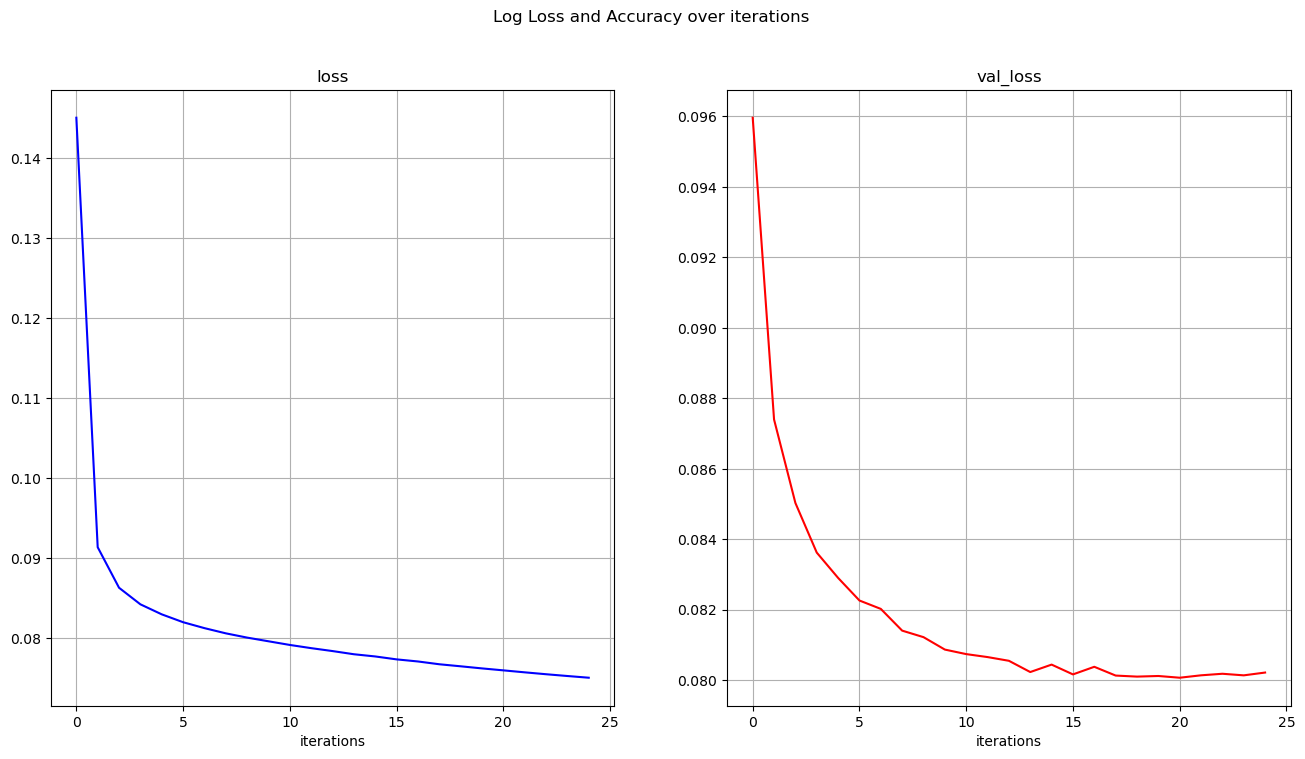

In [33]:
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=25,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
)
graph_history(history, title="Log Loss and Accuracy over iterations")
xhat = autoencoder.predict(x_test)

Now we plot noisy test images beside the reconstructed images. The reconstructed images should keep the main digit shapes while reducing much of the noise.


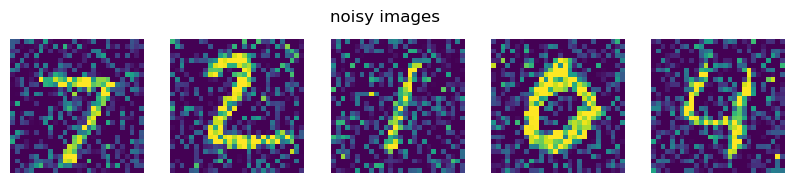

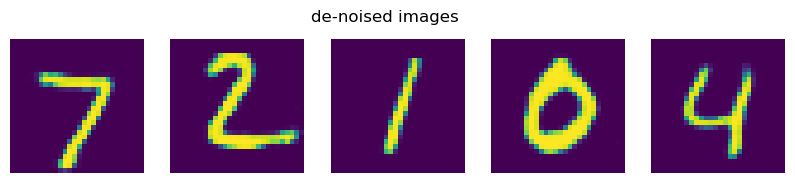

In [34]:
fig1 = plt.figure(figsize=(10, 2))
fig1.suptitle("noisy images")
fig2 = plt.figure(figsize=(10, 2))
fig2.suptitle("de-noised images")

for i, img_index in enumerate(range(5)):
    ax1 = fig1.add_subplot(1, 5, i + 1)
    ax1.imshow(x_test_noisy[img_index].reshape((28, 28)))
    ax1.axis("off")
    ax2 = fig2.add_subplot(1, 5, i + 1)
    ax2.imshow(xhat[img_index].reshape((28, 28)))
    ax2.axis("off")

### <a id="toc-exercise-1"></a>**Exercise 1**
In this exercise, you will use the encoder part of an autoencoder for low-dimensional data visualization.

- Create an autoencoder with the `Autoencoder` class and set the latent dimension to 3.
- Train the model using `x_train` as both the input and target.
- Validate the model using `x_test` as both the input and target.
- Apply the `.encoder` layer to `x_test` to get a 3-dimensional representation.
- Display the encoded output using the `plot_code` helper function.


In [35]:
# write your own code here according to the instructions above

autoencoder = Autoencoder(3)
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
)
h = autoencoder.encoder(x_test)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3698 - val_loss: 0.2768
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2695 - val_loss: 0.2584
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2472 - val_loss: 0.2385
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2365 - val_loss: 0.2330
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2325 - val_loss: 0.2298
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2299 - val_loss: 0.2275
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2279 - val_loss: 0.2257
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2264 - val_loss: 0.2242
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2251 - val_loss: 0.2230
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2241 - val_loss: 0.2219
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2232 - val_loss: 0.2211
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

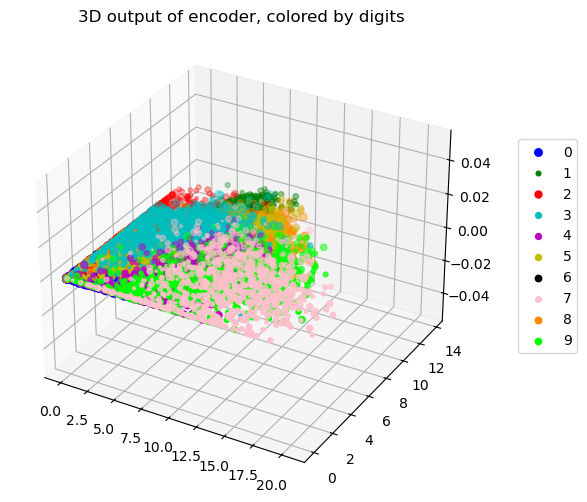

In [36]:
plot_code(h, y_test)

### <a id="toc-exercise-2"></a>**Exercise 2**


In this exercise, you will work with the Fashion MNIST dataset from Keras. You will train an autoencoder to reconstruct clothing images and then examine how well it performs.


In [37]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print(x_train.shape)

(60000, 28, 28)


The images are 28 by 28 pixels. Before passing them to this Dense-layer autoencoder, we flatten each image into a vector of 784 values.


In [38]:
x_temp = layers.Flatten()(x_train)
x_temp_test = layers.Flatten()(x_test)
x_temp.shape, x_temp_test.shape

(TensorShape([60000, 784]), TensorShape([10000, 784]))

In [39]:
encoding_dim = 3
autoencoder = Autoencoder(encoding_dim)

autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
history = autoencoder.fit(
    x_temp,
    x_temp,
    epochs=25,
    batch_size=256,
    shuffle=True,
    validation_data=(x_temp_test, x_temp_test),
)

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5100 - val_loss: 0.4199
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4003 - val_loss: 0.3930
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3877 - val_loss: 0.3860
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3820 - val_loss: 0.3814
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3780 - val_loss: 0.3780
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3747 - val_loss: 0.3751
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3719 - val_loss: 0.3724
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3695 - val_loss: 0.3701
Epoch 9/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3673 - val_loss: 0.3680
Epoch 10/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3654 - val_loss: 0.3662
Epoch 11/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3638 - val_loss: 0.3648
Epoch 12/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

With a latent dimension of only 3, the autoencoder cannot reconstruct the Fashion MNIST images very well. These images are more complex than simple digit images, so we need a more powerful model to represent them accurately.


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 228us/step


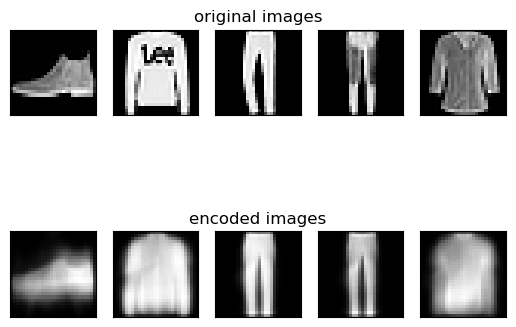

In [40]:
xhat = autoencoder.predict(x_temp_test)
plot_images(x_test, xhat, start=0, stop=5)

## <a id="toc-deep-autoencoders"></a>**Deep Autoencoders**


Like deep neural networks, adding more layers to the encoder and decoder will grant your autoencoders more representational power, allowing you to solve increasingly complex problems. For example, the reconstructed images of the fashion MNIST dataset plotted above did not retain enough features of the original images, so people will instantly recognize a shoe by looking at the first reconstructed image. Analogous to the fact that deep neural networks can learn and extract more complex features from the data than shallow neural networks, a deep autoencoder will also be able to do a better job in tasks that involve complex data than shallow autoencoders.

Let's create a deep autoencoder class, analogous to creating a deep neural network:


In [41]:
class Deep_Autoencoder(Model):
    def __init__(self, latent_dim_1, latent_dim_2):
        super(Deep_Autoencoder, self).__init__()
        self.latent_dim_1 = latent_dim_1
        self.latent_dim_1 = latent_dim_2
        self.encoder = Sequential(
            [
                layers.Flatten(),
                Dense(latent_dim_1, activation="relu"),
                Dense(latent_dim_2, activation="relu"),
            ]
        )
        self.decoder = tf.keras.Sequential(
            [
                Dense(latent_dim_1, activation="relu"),
                Dense(784, activation="sigmoid"),
                Reshape((28, 28)),
            ]
        )

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

We have the encoder:

```encoder = Sequential([layers.Flatten(),Dense(latent_dim_1, activation='relu'),Dense(latent_dim_2, activation='relu')])```

We add a flattening layer for convenience as we will input rectangular image tensors. The encoder consists of two linear layers with Relu activations. Each layer, in this case, gets consistently smaller.

We have the decoder: 

```decoder = tf.keras.Sequential([ Dense(latent_dim_1, activation='relu'),Dense(784, activation='sigmoid'),Reshape((28, 28))])```

which consists of two linear layers. The first layer has a Relu activation; the second layer has a sigmoid activation. For convenience, we add a layer to reshape the output to a rectangular image.

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module5/L2/deep_ae.png" width="70%" style="vertical-align:middle;margin:15px 0px"></center>

By doing so, we create a deep autoencoder object; We set the output shape of each layer smaller and smaller until the latent dimension reaches three. Let's train the model.


In [42]:
latent_dim_1 = 128
latent_dim_2 = 3
deep_autoencoder = Deep_Autoencoder(
    latent_dim_1=latent_dim_1, latent_dim_2=latent_dim_2
)


deep_autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
history = deep_autoencoder.fit(
    x_train,
    x_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4260 - val_loss: 0.3575
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3418 - val_loss: 0.3348
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3295 - val_loss: 0.3288
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3250 - val_loss: 0.3255
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3226 - val_loss: 0.3238
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3209 - val_loss: 0.3221
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3196 - val_loss: 0.3210
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3185 - val_loss: 0.3199
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3177 - val_loss: 0.3192
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3170 - val_loss: 0.3188
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3164 - val_loss: 0.3185
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

We plot the output; we can see the reconstructed images look similar to the original images; this is even after the dimension has been reduced to three in the bottleneck.


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 314us/step


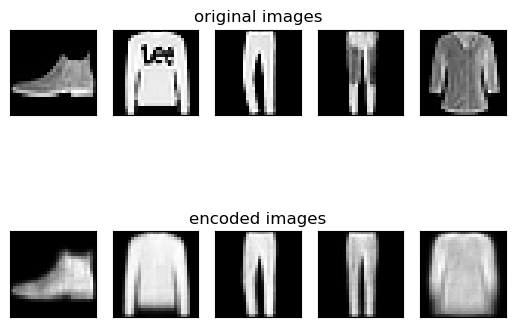

In [43]:
xhat = deep_autoencoder.predict(x_test)
plot_images(x_test, xhat, start=0, stop=5)

### <a id="toc-loading-images-from-a-directory-for-autoencoders"></a>**Loading Images From a Directory for Autoencoders**


Loading images from a directory for Autoencoders is similar to that for neural networks, but there are also several small differences. Like neural networks we create an object using ```image_dataset_from_directory``` that consists of human faces.


In [44]:
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module5/L2/face_data.zip"
await skillsnetwork.prepare(dataset_url, overwrite=True)

  0%|          | 0/47424 [00:00<?, ?it/s]

Saved to '.'


In [45]:
img_height = 50
img_width = 50
batch_size = 100
data_dir_face = os.path.join(os.getcwd(), "face_data")

In [46]:
Xface = tf.keras.utils.image_dataset_from_directory(
    data_dir_face,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode="grayscale",
)

Found 23708 files belonging to 1 classes.
Using 18967 files for training.


We will copy the object as we will use it multiple times 


In [47]:
X_face_copy = copy.copy(Xface)

Unlike neural networks, autoencoders have no labels. Instead, the input and output are both a set of features $\textbf{X}$. Therefore you have to map the output from the directory object from $(\textbf{x},\textbf{y})$ to $(\textbf{x},\textbf{x}$), using the following function:


In [48]:
def change_inputs(images, labels):

    return images, images

To apply the transform to the image, we use the ```apply``` method to apply the function ```change_inputs``` :


In [49]:
X_face_1 = Xface.map(change_inputs)

We will convert the object to an iterator so we can cycle through the samples:


In [50]:
X_iter = iter(X_face_1)

We see each output is two tuples, each an array of 100 50x50 images 


In [51]:
images1, images2 = next(X_iter)

In [52]:
print("images1 shape {}, and images2 {}".format(images1.shape, images2.shape))

images1 shape (100, 50, 50, 1), and images2 (100, 50, 50, 1)


We can plot some of the images using the function ```display_auto``` where ```n``` is the sample in a batch and ```B``` is the batch number, assuming next has only been called once 


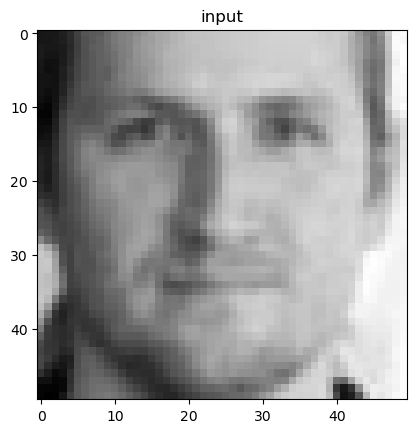

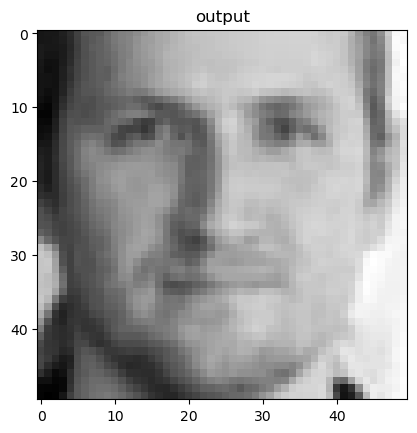

In [53]:
display_auto(X_iter, n=1, B=1)

we can also apply other transformations like normalizing the image 


In [54]:
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

In many cases we would like a corrupted version of the image $\textbf{x},\tilde{\textbf{x}}$. Let's construct a from-the-directory object that can be used to train an autoencoder to deblur an image. In many applications like noise removal, you add noise to $\textbf{x}$ and get $\tilde{\textbf{x}}$. In this case, the input  $\tilde{\textbf{x}}$ will be a blurred image.


In [55]:
def blur_image(images, labels):

    x = normalization_layer(images)
    x_b = a_conv(x)
    return x_b, x

We normalize the image and then blur the image using a filter, we apply the function to the dataset object.


In [56]:
Xface = Xface.map(blur_image)

We see the input image is blurred:


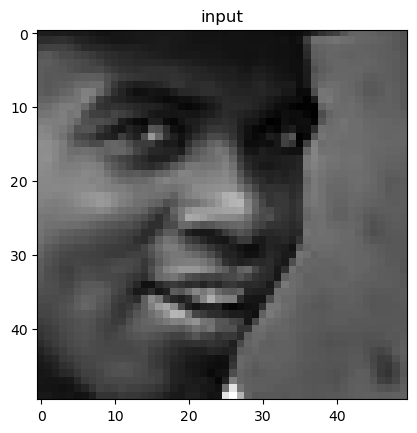

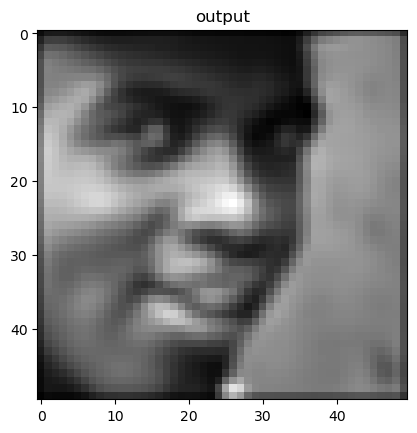

In [57]:
Xiter = iter(Xface)
display_auto(Xiter, n=1, B=1)

## <a id="toc-convolutional-autoencoders"></a>**Convolutional Autoencoders**


Analogous to Convolutional neural networks, there are Convolutional Autoencoders (CAEs). Compared to the Autoencoders with fully connected layers, Convolutional Autoencoders with Conv2D layers do a better job encapsulating the pixel data's underlying patterns.

The following is an illustration of the CAE's architecture:

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module5/L2/CAE.png" width="80%" style="vertical-align:middle;margin:15px 0px"></center>

Image from [this article](https://ai.plainenglish.io/convolutional-autoencoders-cae-with-tensorflow-97e8d8859cbe?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01). 

We can build a convolutional autoencoder class:


In [58]:
class CNN_Autoencoder(Model):
    def __init__(self):
        super(CNN_Autoencoder, self).__init__()
        self.encoder = tf.keras.Sequential(
            [
                layers.Input(shape=(50, 50, 1)),
                Conv2D(
                    16, (3, 3), activation="relu", padding="same", strides=1
                ),
                Conv2D(8, (3, 3), activation="relu", padding="same", strides=1),
            ]
        )

        self.decoder = tf.keras.Sequential(
            [
                Conv2DTranspose(
                    8,
                    kernel_size=3,
                    strides=1,
                    activation="relu",
                    padding="same",
                ),
                Conv2DTranspose(
                    16,
                    kernel_size=3,
                    strides=1,
                    activation="relu",
                    padding="same",
                ),
                Conv2D(
                    1, kernel_size=(3, 3), activation="sigmoid", padding="same"
                ),
            ]
        )

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

The encoder consists of several convolution layers that will produce an activation map:

```encoder = tf.keras.Sequential([layers.Input(shape=(50, 50, 1)),Conv2D(16, (3, 3), activation='relu', padding='same', strides=1),Conv2D(8, (3, 3), activation='relu', padding='same', strides=1)])```


The decoder consists of several transposed convolutional or de-convolutional layers; the final layer is a convolutional layer that combines the activation maps of the previous transposed convolutional layer to form an image:

```decoder = tf.keras.Sequential([Conv2DTranspose(8, kernel_size=3, strides=1, activation='relu', padding='same'),Conv2DTranspose(16, kernel_size=3, strides=1, activation='relu', padding='same'),Conv2D(1, kernel_size=(3, 3), activation='sigmoid', padding='same')])```


Let's create a ```CNN_Autoencoder``` object


In [59]:
cnn_autoencoder_face = CNN_Autoencoder()

Let's train the CNN autoencoder and use it to de-blur an image by minimizing the difference between $\tilde{\textbf{x}}$ and $\textbf{x}$. Note that for training, we pass in `Xface`, which can be seen as an image data generator that will feed our model pairs of blurred images and original image. We expect the model to learn and minimize the difference between the two and eventually be able to recover the original image from a blurred image.


Epoch 1/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0126
Epoch 2/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0022
Epoch 3/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0017
Epoch 4/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0015
Epoch 5/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0014
Epoch 6/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0013
Epoch 7/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0012
Epoch 8/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0011
Epoch 9/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0010
Epoch 10/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.8349e-04


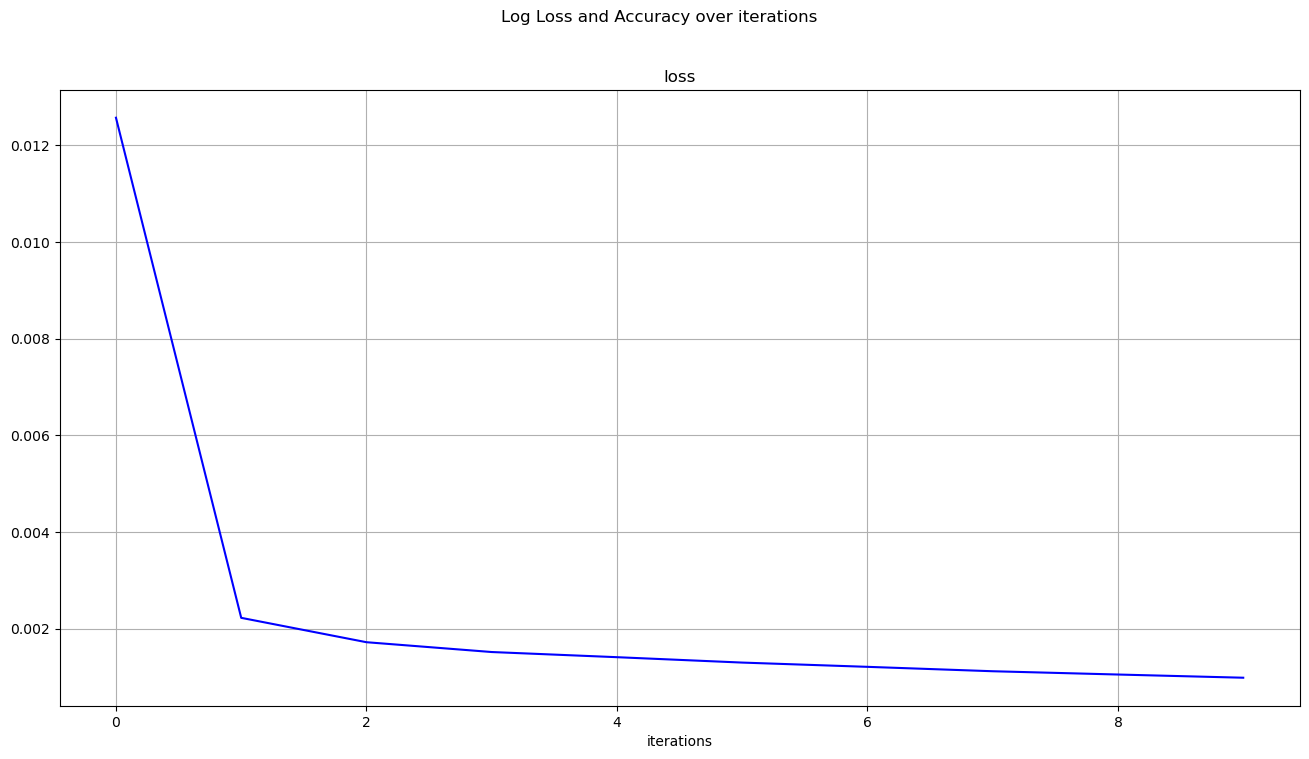

In [60]:
cnn_autoencoder_face.compile(optimizer="adam", loss="mse")
history = cnn_autoencoder_face.fit(Xface, epochs=10)

graph_history(history, title="Log Loss and Accuracy over iterations")

We take some samples from the set of blurred images and use the trained autoencoder to deblur the images and compare them to the blurred images.


In [61]:
x = next(Xiter)
Xhat = cnn_autoencoder_face.predict(x[0])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


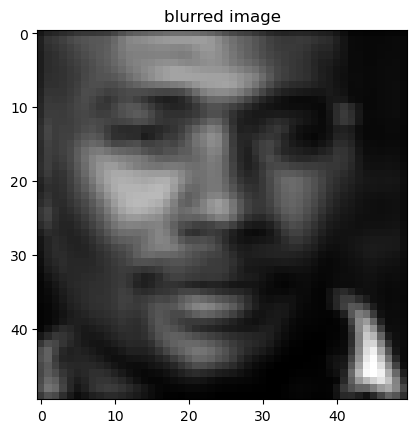

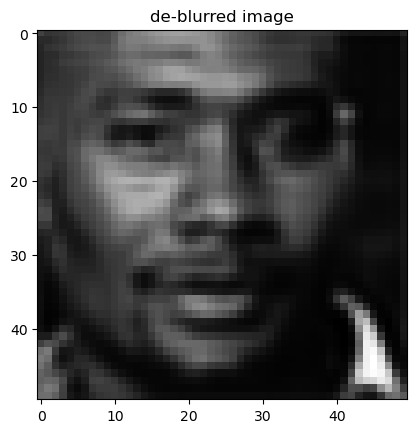

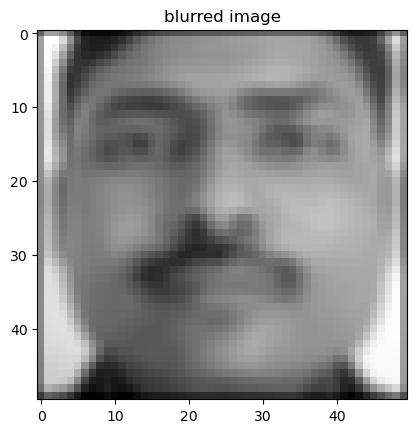

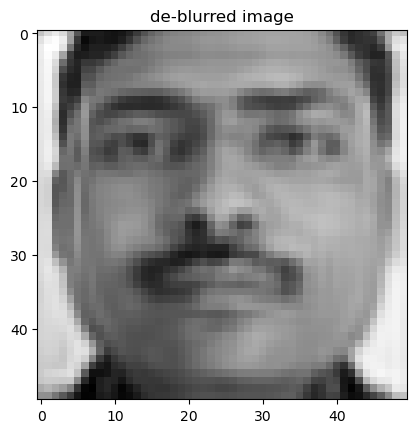

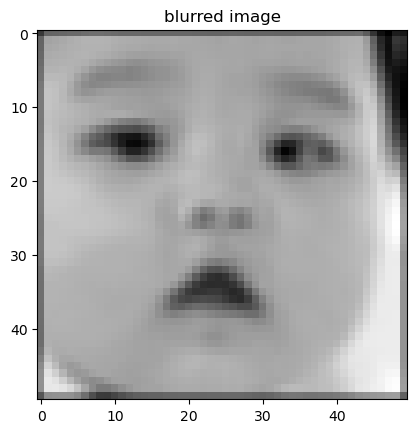

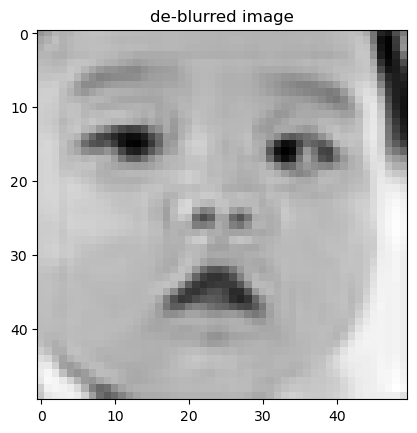

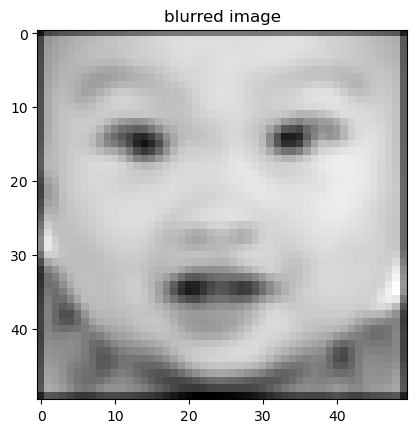

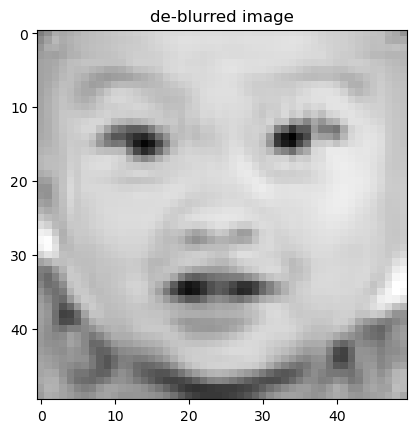

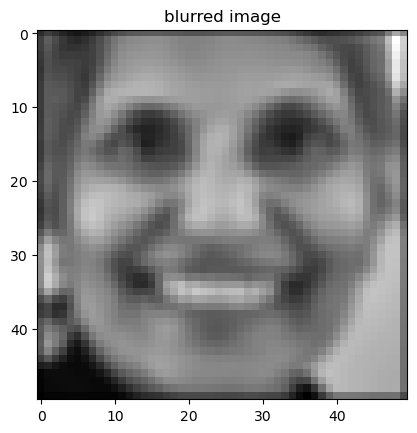

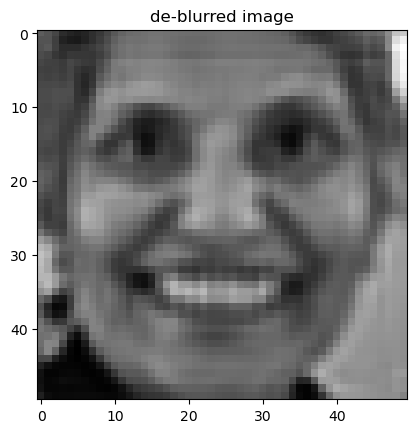

In [62]:
for image_b, image_db in zip(x[0].numpy()[0:5, :, :, 0], Xhat[0:5, :, :, 0]):
    plt.imshow(image_b, cmap="gray")
    plt.title("blurred image")
    plt.show()
    plt.imshow(image_db, cmap="gray")
    plt.title("de-blurred image")
    plt.show()

We see that as the CNN autoencoder can learn the complex image features well, it can be used to de-blur the blurred images and represent the features more clearly.


## **Author**


<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


[Roxanne Li](https://www.linkedin.com/in/roxanne-li/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01) is a Data Science intern at IBM Skills Network, entering level-5 study in the Mathematics & Statistics undergraduate Coop program at McMaster University.

Su Wu

## **Change Log**

| Date (YYYY-MM-DD) | Version | Changed By | Change Description                 |
| ----------------- | ------- | ---------- | ---------------------------------- |
| 2022-03-28        | 0.1     | David Pasternak      | Created Lab    |
| 2022-05-10        | 0.2     | Sam Prokopchuk      | Complete Draft of Lab    |
| 2022-08-05        | 0.3     | Roxanne Li      | Review and edit Lab    |
| 2022-09-09        | 0.3     | Steve Hord      | QA pass edits          |
| 2026-05-28     | 0.4     | Su Wu| Documentation and script edits    |

## <h3 align="center"> © IBM Corporation 2022. All rights reserved. <h3/>
